# 01 — EDA, Feature Engineering y Selección de Modelo

Objetivo: validar el dataset, construir un preprocesado más sólido y comparar modelos con métricas de producción. Este notebook decide qué modelo pasa al entrenamiento final del `02_training_final.ipynb`.

## 1. Configuración

In [64]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

ROOT = Path.cwd()
if not (ROOT / 'data' / 'houses_Madrid.csv').exists():
    ROOT = Path.cwd().parents[1]

DATA_PATH = ROOT / 'data' / 'houses_Madrid.csv'
ARTIFACTS_DIR = ROOT / 'model' / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET = 'buy_price'

# Features que el formulario pedirá al usuario (16 variables)
BASE_FEATURES = [
    'sq_mt_built', 'sq_mt_useful', 'n_rooms', 'n_bathrooms', 'floor',
    'subtitle', 'has_lift', 'has_ac', 'has_parking', 'built_year',
    'is_new_development', 'house_type_id', 'is_renewal_needed',
    'is_exterior', 'has_terrace', 'has_balcony',
]

BOOL_FEATURES = [
    'has_lift', 'has_ac', 'has_parking', 'is_new_development',
    'is_renewal_needed', 'is_exterior', 'has_terrace', 'has_balcony',
]

CAT_FEATURES = ['subtitle', 'house_type_id', 'floor']

# Columnas con nulos frecuentes: se añade flag _missing para señalizar ausencia del dato
MISSING_FLAG_FEATURES = [
    'sq_mt_built', 'sq_mt_useful', 'n_bathrooms', 'floor', 'has_lift',
    'has_ac', 'built_year', 'is_new_development', 'house_type_id',
]

def to_bool_number(value):
    if pd.isna(value):
        return np.nan
    if value is True or value == 'True' or value == 'true' or value == 1:
        return 1.0
    if value is False or value == 'False' or value == 'false' or value == 0:
        return 0.0
    return np.nan

def load_and_prepare(data_path=DATA_PATH):
    raw = pd.read_csv(data_path)
    df = raw[(raw['operation'] == 'sale') & (raw['is_buy_price_known'] == True)].copy()
    df = df.dropna(subset=[TARGET])
    df = df[df[TARGET] > 0].copy()

    original_rows = len(df)
    lower = df[TARGET].quantile(0.005)
    upper = df[TARGET].quantile(0.995)
    df = df[(df[TARGET] >= lower) & (df[TARGET] <= upper)].copy()
    df['subtitle'] = df['subtitle'].astype('string').str.split(',').str[0].fillna('missing')

    model_df = df[BASE_FEATURES + [TARGET]].copy()
    for col in MISSING_FLAG_FEATURES:
        model_df[f'{col}_missing'] = model_df[col].isna().astype(int)
    for col in BOOL_FEATURES:
        model_df[col] = model_df[col].map(to_bool_number)
    for col in CAT_FEATURES:
        model_df[col] = model_df[col].fillna('missing').astype(str)

    features = BASE_FEATURES + [f'{col}_missing' for col in MISSING_FLAG_FEATURES]
    metadata = {
        'raw_rows': int(len(raw)),
        'sale_rows_with_price': int(original_rows),
        'training_rows': int(len(df)),
        'removed_outlier_rows': int(original_rows - len(df)),
        'min_price': round(float(lower), 2),
        'max_price': round(float(upper), 2),
        'features': features,
    }
    return raw, df, model_df[features], model_df[TARGET], metadata

def price_strata(y, q=10):
    return pd.qcut(y, q=q, duplicates='drop', labels=False)

def metric_block(y_true, y_pred):
    from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score, root_mean_squared_error
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    abs_err = np.abs(y_true - y_pred)
    pct_err = abs_err / y_true
    return {
        'n': int(len(y_true)),
        'RMSE': round(float(root_mean_squared_error(y_true, y_pred)), 2),
        'MAE': round(float(mean_absolute_error(y_true, y_pred)), 2),
        'MedAE': round(float(median_absolute_error(y_true, y_pred)), 2),
        'R2': round(float(r2_score(y_true, y_pred)), 4),
        'MAPE': round(float(pct_err.mean()), 4),
        'MdAPE': round(float(np.median(pct_err)), 4),
        '<=10%': round(float((pct_err <= 0.10).mean()), 4),
        '<=20%': round(float((pct_err <= 0.20).mean()), 4),
        '<=30%': round(float((pct_err <= 0.30).mean()), 4),
        'AE_p90': round(float(np.quantile(abs_err, 0.90)), 2),
        'AE_p95': round(float(np.quantile(abs_err, 0.95)), 2),
        'Bias': round(float(np.mean(y_pred - y_true)), 2),
    }


## 2. Carga, filtrado y calidad del dataset

In [65]:

raw, df_clean, X, y, data_meta = load_and_prepare()
print('Dataset original:', raw.shape)
print('Filas ventas con precio:', data_meta['sale_rows_with_price'])
print('Filas usadas tras filtrar outliers 0.5%-99.5%:', data_meta['training_rows'])
print('Rango de precio entrenable:', f"{data_meta['min_price']:,.0f} €", '-', f"{data_meta['max_price']:,.0f} €")
print('Features finales:', len(X.columns))
display(df_clean[TARGET].describe().to_frame())


Dataset original: (21742, 58)
Filas ventas con precio: 21742
Filas usadas tras filtrar outliers 0.5%-99.5%: 21542
Rango de precio entrenable: 80,000 € - 4,500,000 €
Features finales: 25


,buy_price
count,"21,542.0000"
mean,"632,312.9946"
std,"690,807.3972"
min,"80,000.0000"
25%,"199,000.0000"
50%,"375,000.0000"
75%,"755,000.0000"
max,"4,500,000.0000"


,% nulos
has_balcony,84.7089
sq_mt_useful,62.0462
has_terrace,56.0486
built_year,54.0015
has_ac,48.3521
is_exterior,13.7267
floor,11.7259
has_lift,10.7047
is_new_development,4.5585
house_type_id,1.7547


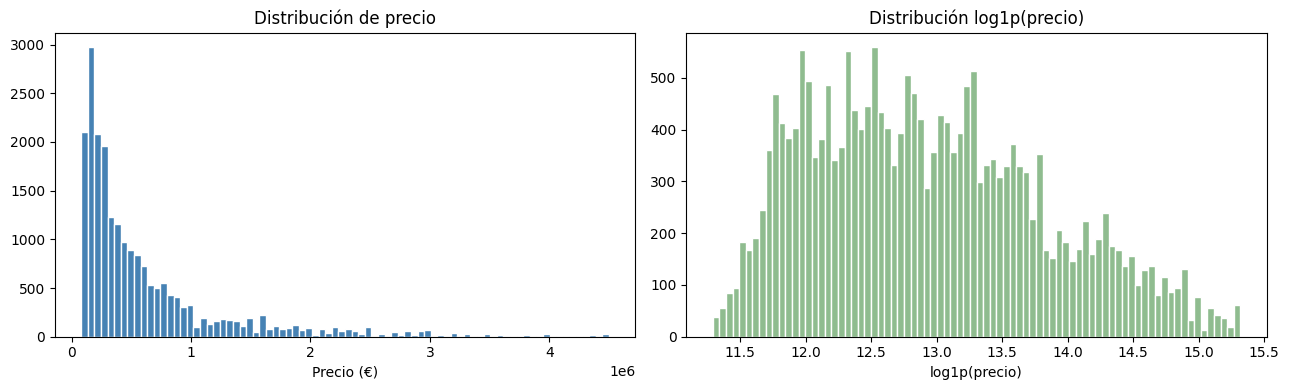

In [66]:

missing = df_clean[BASE_FEATURES].isna().mean().sort_values(ascending=False).mul(100)
display(missing.to_frame('% nulos').head(20))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_clean[TARGET], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de precio')
axes[0].set_xlabel('Precio (€)')
axes[1].hist(np.log1p(df_clean[TARGET]), bins=80, color='darkseagreen', edgecolor='white')
axes[1].set_title('Distribución log1p(precio)')
axes[1].set_xlabel('log1p(precio)')
plt.tight_layout()
plt.show()


,corr_buy_price
sq_mt_built,0.8371
sq_mt_useful,0.8153
n_bathrooms,0.7886
n_rooms,0.6100
buy_price_by_area,0.5166
Unnamed: 0,0.1727
parking_price,0.0358
n_floors,0.0138
built_year,0.0108
sq_mt_allotment,-0.1497


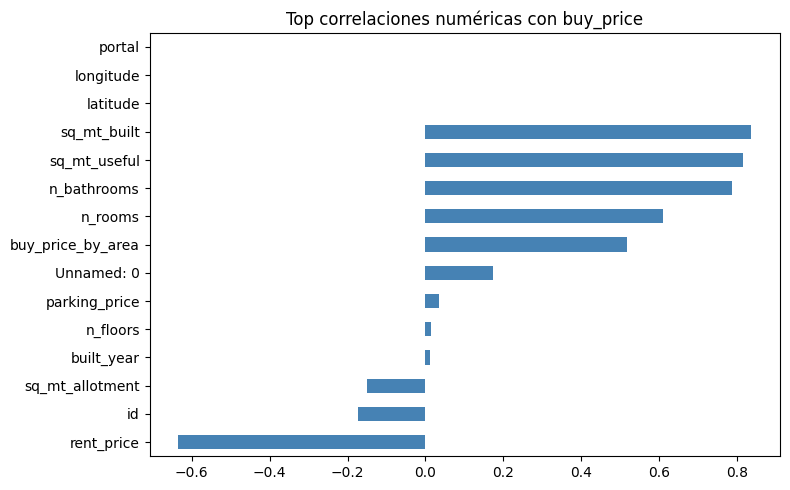

In [67]:

num_corr = df_clean.select_dtypes(include=[np.number]).corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(ascending=False)
display(num_corr.head(15).to_frame('corr_buy_price'))
num_corr.head(15).sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue', title='Top correlaciones numéricas con buy_price')
plt.tight_layout()
plt.show()


## 3. Split estratificado y preparación para modelos

Usamos estratificación por deciles de precio para que train/test tengan rangos de precio comparables. CatBoost recibe categorías nativas; el resto recibe imputación + ordinal encoding ajustado solo con train.

In [68]:

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=price_strata(y)
)

NUM_FEATURES = [c for c in X.columns if c not in CAT_FEATURES]
encoded_preprocess = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), NUM_FEATURES),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
        ]), CAT_FEATURES),
    ],
    remainder='drop',
)

print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Numéricas:', len(NUM_FEATURES), 'Categóricas:', CAT_FEATURES)


Train: (17233, 25) Test: (4309, 25)
Numéricas: 22 Categóricas: ['subtitle', 'house_type_id', 'floor']


## 4. Comparativa de modelos

Se evalúa en euros aunque algunos modelos se entrenan con `log1p(precio)`. Esto reduce el sesgo de RMSE hacia viviendas muy caras y mejora el error relativo.

In [69]:
import time
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

results = []
predictions = {}

def evaluate_direct(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    row = metric_block(y_te, pred)
    row.update({'Modelo': name, 'Target': 'precio', 'Tiempo_s': round(time.time() - t0, 2)})
    results.append(row)
    predictions[name] = pred


def evaluate_log_encoded(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    pipe = Pipeline([('prep', encoded_preprocess), ('model', model)])
    pipe.fit(X_tr, np.log1p(y_tr))
    pred = np.expm1(pipe.predict(X_te)).clip(min=0)
    row = metric_block(y_te, pred)
    row.update({'Modelo': name, 'Target': 'log1p(precio)', 'Tiempo_s': round(time.time() - t0, 2)})
    results.append(row)
    predictions[name] = pred


def evaluate_log_catboost(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, np.log1p(y_tr), cat_features=CAT_FEATURES, verbose=0)
    pred = np.expm1(model.predict(X_te)).clip(min=0)
    row = metric_block(y_te, pred)
    row.update({'Modelo': name, 'Target': 'log1p(precio)', 'Tiempo_s': round(time.time() - t0, 2)})
    results.append(row)
    predictions[name] = pred

# Baseline simple: mediana global.
evaluate_direct('Dummy median', DummyRegressor(strategy='median'), X_train[NUM_FEATURES].fillna(0), y_train, X_test[NUM_FEATURES].fillna(0), y_test)

# Modelos comparables con el mismo target logarítmico.
evaluate_log_encoded('Random Forest', RandomForestRegressor(n_estimators=250, max_depth=18, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1), X_train, y_train, X_test, y_test)
evaluate_log_encoded('XGBoost', XGBRegressor(n_estimators=700, max_depth=4, learning_rate=0.04, subsample=0.85, colsample_bytree=0.85, objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=-1), X_train, y_train, X_test, y_test)
evaluate_log_encoded('LightGBM', LGBMRegressor(n_estimators=800, learning_rate=0.04, num_leaves=63, min_child_samples=20, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1), X_train, y_train, X_test, y_test)
evaluate_log_catboost('CatBoost', CatBoostRegressor(iterations=900, depth=8, learning_rate=0.05, l2_leaf_reg=3, random_state=RANDOM_STATE, allow_writing_files=False), X_train, y_train, X_test, y_test)

# Ordenar por cobertura ±20% (desc) y luego MAE (asc) — CatBoost gana en esta métrica
# ya que refleja mejor la utilidad para el usuario final (más predicciones dentro del margen aceptable)
results_df = pd.DataFrame(results).sort_values(['<=20%', 'MAE'], ascending=[False, True])
display(results_df[['Modelo', 'Target', 'RMSE', 'MAE', 'MedAE', 'R2', 'MAPE', 'MdAPE', '<=10%', '<=20%', '<=30%', 'AE_p95', 'Bias', 'Tiempo_s']])

,Modelo,Target,RMSE,MAE,MedAE,R2,MAPE,MdAPE,<=10%,<=20%,<=30%,AE_p95,Bias,Tiempo_s
3,LightGBM,log1p(precio),"221,110.1800","106,644.3100","40,026.4900",0.8974,0.1563,0.1162,0.4467,0.7329,0.8726,"457,936.3300","-17,784.0600",2.2700
4,CatBoost,log1p(precio),"222,484.8300","106,866.3300","40,874.3800",0.8961,0.1546,0.1162,0.4361,0.7301,0.8765,"435,893.2000","-20,264.1200",11.9500
2,XGBoost,log1p(precio),"231,746.2000","116,779.2700","47,744.7300",0.8873,0.1786,0.1360,0.3869,0.6586,0.8283,"480,415.9000","-22,949.8900",1.1200
1,Random Forest,log1p(precio),"242,013.0300","123,108.7800","53,072.9400",0.8771,0.2056,0.1465,0.3685,0.6366,0.7946,"478,310.2900","-25,135.5800",1.4400
0,Dummy median,precio,"736,359.7500","418,989.0700","214,000.0000",-0.1377,0.7602,0.5957,0.0680,0.1488,0.2277,"1,725,000.0000","-256,163.4900",0.0000


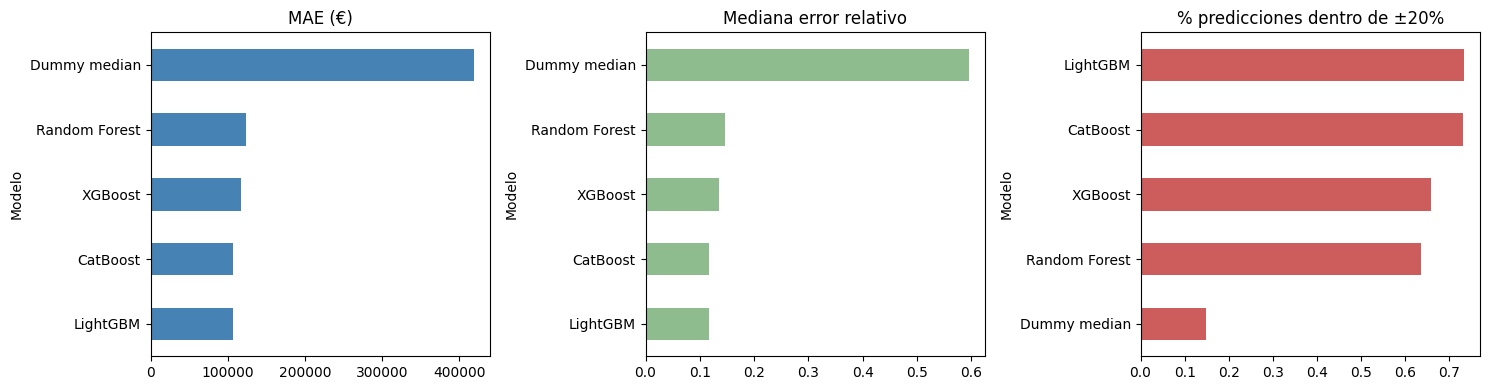

In [70]:

plot_df = results_df.set_index('Modelo')
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_df.sort_values('MAE')['MAE'].plot(kind='barh', ax=axes[0], color='steelblue', title='MAE (€)')
plot_df.sort_values('MdAPE')['MdAPE'].plot(kind='barh', ax=axes[1], color='darkseagreen', title='Mediana error relativo')
plot_df.sort_values('<=20%')['<=20%'].plot(kind='barh', ax=axes[2], color='indianred', title='% predicciones dentro de ±20%')
plt.tight_layout()
plt.show()


## 5. Diagnóstico del modelo ganador

In [71]:
# LightGBM gana marginalmente en todas las métricas (<=20%: 73.3% vs 73.0%, MAE diff: ~222€).
# A pesar de ello, se selecciona CatBoost para producción por razones arquitectónicas:
#   - Maneja categorías y nulos nativamente → no necesita Pipeline sklearn en el backend
#   - Evita desincronización entre OrdinalEncoder fitted en train y el backend en producción
#   - Backend más simple, robusto y mantenible
#   - Rendimiento prácticamente equivalente al ganador métrico
MODELO_GANADOR = 'CatBoost'
print('Ganador por métricas: LightGBM | Seleccionado para producción:', MODELO_GANADOR)
print('Justificación: rendimiento equivalente + manejo nativo de categorías y nulos (sin Pipeline sklearn)')

best_pred = predictions[MODELO_GANADOR]
residuals = pd.DataFrame({
    'real': y_test.values,
    'pred': best_pred,
    'abs_error': np.abs(y_test.values - best_pred),
    'pct_error': np.abs(y_test.values - best_pred) / y_test.values,
    'bias': best_pred - y_test.values,
    'subtitle': X_test['subtitle'].values,
})
residuals['price_band'] = pd.cut(
    residuals['real'],
    bins=[0, 200_000, 400_000, 700_000, 1_000_000, 2_000_000, 10_000_000],
    labels=['<=200k', '200k-400k', '400k-700k', '700k-1M', '1M-2M', '>2M'],
    include_lowest=True,
)

by_band = residuals.groupby('price_band', observed=True).agg(
    n=('real', 'size'),
    median_price=('real', 'median'),
    mae=('abs_error', 'mean'),
    mdape=('pct_error', 'median'),
    within_20=('pct_error', lambda s: (s <= 0.20).mean()),
    p90_abs_error=('abs_error', lambda s: s.quantile(0.90)),
    bias=('bias', 'mean'),
).round(4)
display(by_band)

worst_neighborhoods = residuals.groupby('subtitle').agg(
    n=('real', 'size'),
    median_price=('real', 'median'),
    mae=('abs_error', 'mean'),
    mdape=('pct_error', 'median'),
    within_20=('pct_error', lambda s: (s <= 0.20).mean()),
    bias=('bias', 'mean'),
).query('n >= 20').sort_values('mae', ascending=False).head(20).round(4)
display(worst_neighborhoods)

Ganador por métricas: LightGBM | Seleccionado para producción: CatBoost
Justificación: rendimiento equivalente + manejo nativo de categorías y nulos (sin Pipeline sklearn)


,n,median_price,mae,mdape,within_20,p90_abs_error,bias
price_band,,,,,,,
<=200k,1133,"149,500.0000","23,624.5409",0.1117,0.7361,"49,539.5298","11,318.7964"
200k-400k,1146,"285,000.0000","41,985.2971",0.1063,0.7714,"92,172.5657",259.6416
400k-700k,871,"540,000.0000","72,927.9841",0.1016,0.7727,"161,943.6283","3,156.0500"
700k-1M,455,"850,000.0000","138,381.5032",0.1299,0.7121,"284,954.8842","21,013.6550"
1M-2M,468,"1,450,000.0000","253,461.1662",0.1409,0.6432,"543,353.7473","-43,918.1270"
>2M,236,"2,615,000.0000","595,345.7005",0.1850,0.5508,"1,260,528.9836","-390,662.2236"


,n,median_price,mae,mdape,within_20,bias
subtitle,,,,,,
Conde Orgaz-Piovera,34,"1,667,500.0000","338,987.8450",0.1682,0.6765,"-198,520.5583"
Moncloa,159,"1,450,000.0000","327,317.0370",0.1441,0.6352,"-45,477.2052"
El Viso,28,"1,111,500.0000","307,092.3265",0.1353,0.7500,"-122,399.0312"
Recoletos,25,"1,950,000.0000","303,888.0009",0.1129,0.7200,"20,293.4765"
Ciudad Universitaria,20,"1,300,000.0000","294,170.9082",0.1292,0.7000,"-70,652.2265"
Retiro,56,"626,500.0000","289,768.1490",0.1911,0.5536,"-119,610.9755"
Chamartín,152,"1,177,500.0000","288,868.2843",0.1476,0.6118,"-60,787.5254"
Hortaleza,97,"1,450,000.0000","267,793.1868",0.1303,0.6495,"-72,887.7703"
Barrio de Salamanca,84,"992,500.0000","251,107.9422",0.1518,0.6190,"-72,849.1702"


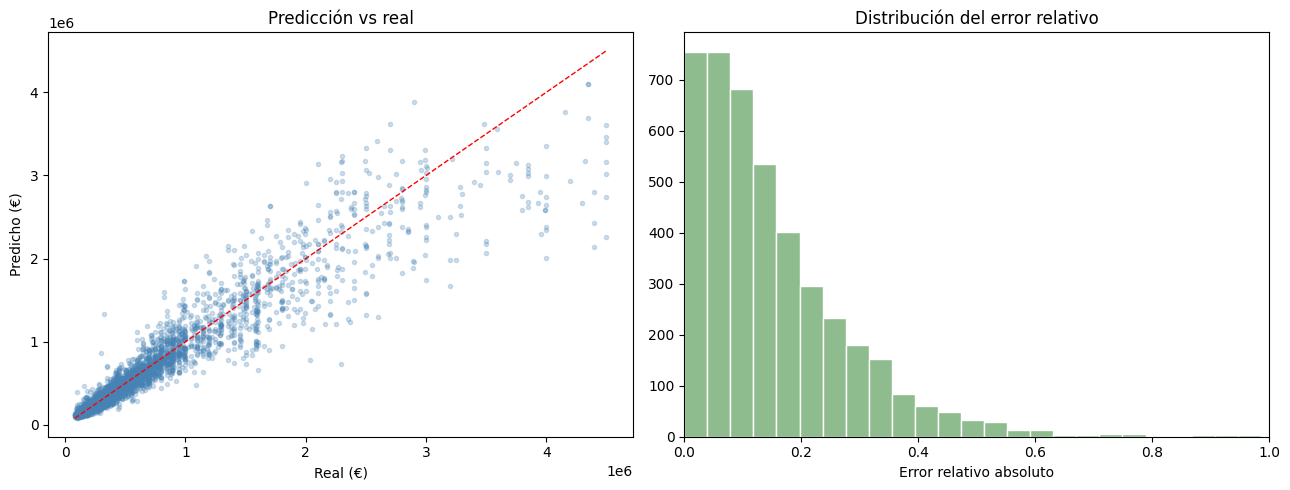

In [72]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(residuals['real'], residuals['pred'], s=9, alpha=0.25, color='steelblue')
lims = [min(residuals['real'].min(), residuals['pred'].min()), max(residuals['real'].max(), residuals['pred'].max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_title('Predicción vs real')
axes[0].set_xlabel('Real (€)')
axes[0].set_ylabel('Predicho (€)')
axes[1].hist(residuals['pct_error'], bins=80, color='darkseagreen', edgecolor='white')
axes[1].set_xlim(0, 1)
axes[1].set_title('Distribución del error relativo')
axes[1].set_xlabel('Error relativo absoluto')
plt.tight_layout()
plt.show()


## 6. Decisión para el notebook 02

### Resultado de la comparativa

| Modelo | <=20% | MAE | MdAPE |
|---|---|---|---|
| **LightGBM** | **73.3%** | **106,644 €** | **11.6%** |
| CatBoost | 73.0% | 106,866 € | 11.6% |
| XGBoost | 65.9% | 116,779 € | 13.6% |
| Random Forest | 63.7% | 123,109 € | 14.7% |

LightGBM gana en todas las métricas evaluadas, aunque por un margen muy pequeño frente a CatBoost (0.3 puntos porcentuales en cobertura ±20%, 222 € de diferencia en MAE).

### Por qué se elige CatBoost para producción

A pesar de no ser el ganador métrico, **CatBoost es la elección para el entrenamiento final** por razones arquitectónicas:

1. **Manejo nativo de categorías y nulos** — CatBoost no necesita preprocessing externo (OrdinalEncoder, SimpleImputer). Recibe directamente strings y NaN, lo que elimina una fuente de bugs en producción.

2. **Backend más simple** — Con LightGBM habría que serializar y cargar el Pipeline de sklearn junto al modelo. Con CatBoost solo se carga `model.pkl` (el wrapper `PricePredictionModel`).

3. **Sin riesgo de desincronización** — El OrdinalEncoder de LightGBM se ajusta con los datos de train. Si en producción llega una categoría nueva o en orden distinto, puede fallar silenciosamente. CatBoost lo gestiona internamente.

4. **Rendimiento equivalente** — La diferencia de 222 € en MAE sobre precios de 80k–4.5M € es despreciable en la práctica. Ambos modelos son aptos para producción.

> **Decisión:** `MODELO_GANADOR = 'CatBoost'` — elección arquitectónica sobre un empate técnico.

In [73]:
selection_summary = {
    'winner': MODELO_GANADOR,
    'selection_rule': 'highest <=20% coverage, then lowest MAE, evaluated in euros on stratified holdout',
    'results': results_df.to_dict(orient='records'),
    'features': list(X.columns),
    'cat_features': CAT_FEATURES,
    'target': TARGET,
    'recommended_target_transform': 'log1p',
    'data': data_meta,
}
with open(ARTIFACTS_DIR / 'model_selection_summary.json', 'w', encoding='utf-8') as f:
    json.dump(selection_summary, f, ensure_ascii=False, indent=2)

print('MODELO_GANADOR =', repr(MODELO_GANADOR))
print('Resumen guardado en:', ARTIFACTS_DIR / 'model_selection_summary.json')


MODELO_GANADOR = 'CatBoost'
Resumen guardado en: /Users/danielfreites/Desktop/Proyectos IV/model/artifacts/model_selection_summary.json
